# Satimage dataset


In [1]:
## Importing
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
from evclust.utils import plotting, display_results_fuzzy_partition, display_results_evidential
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from evclust.datasets import load_satimage
import math

from evclust.ecm import ecm
from evclust.wecm_new_barycenter import wecm
from evclust.wecm_new_barycenter_2 import wecm as wecm2
from evclust.gwecm import gwecm
from evclust.fcm.fcm_keller2000 import fcm as fcm_keller2000
from evclust.fcm.fcm_wang2004 import fcm as fcm_wang2004
from evclust.fcm.fcm_frigui2004 import scad1
from evclust.fcm.fcm_frigui2004 import scad2
from evclust.fcm.ifwfcm_xing2014 import fcm as ifwfcm_xing2014
from evclust.fcm.ifwfcm_kd_xing2014 import fcm as ifwfcm_kd_xing2014

Instances 6434 - Features 36 - Class 6
   92  115  120  94  84  102  106  79  84.1  102.1  ...  134  104.1  88  121  \
0  84  102  106  79  84  102  102  83    80    102  ...  128    100  84  107   
1  84  102  102  83  80  102  102  79    84     94  ...  113     87  84   99   
2  80  102  102  79  84   94  102  79    80     94  ...  104     79  84   99   
3  84   94  102  79  80   94   98  76    80    102  ...  104     79  84  103   
4  80   94   98  76  80  102  102  79    76    102  ...  104     79  79  107   

   128  100  84.3  107  113  87  
0  113   87    84   99  104  79  
1  104   79    84   99  104  79  
2  104   79    84  103  104  79  
3  104   79    79  107  109  87  
4  109   87    79  107  109  87  

[5 rows x 36 columns]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


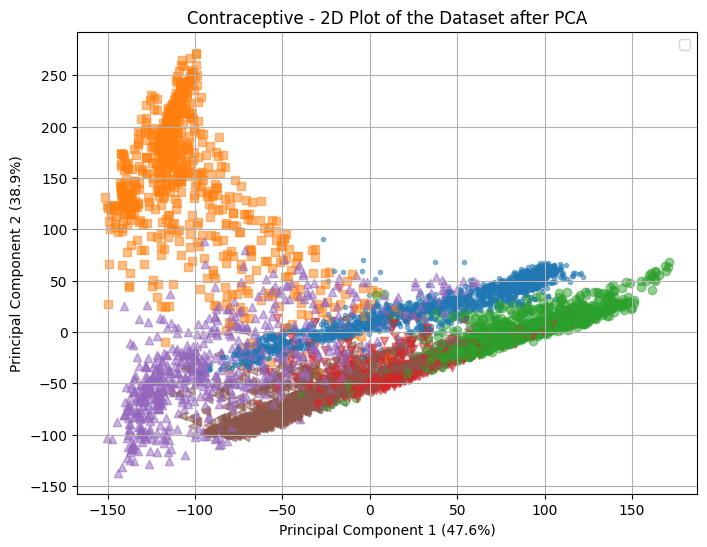

In [2]:

# fetch dataset
df = load_satimage()
X = pd.DataFrame(df.iloc[:, :-1])
y = pd.DataFrame(df.iloc[:, -1])

label_column_nm = y.columns[0]
labels_encoder = LabelEncoder()
numeric_labels = labels_encoder.fit_transform(y[label_column_nm])
plotting(X, y, ds_name="Contraceptive", matrix_plot=False)
c = len(np.unique(numeric_labels))

# Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(scaler.fit_transform(X))

## Traditional ECM

In [3]:
%%capture
# Traditional ECM clustering
delta = np.sqrt(20)
ecm_models = np.array([])
for i in range(5):
    model = ecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", epsi=1e-5)
    ecm_models = np.append(ecm_models, model)

ecm_models = sorted(ecm_models, key=lambda x: x['crit'])

J values: [227.65346151328185, 227.6534627113017, 227.65346275345763, 227.65348683021557, 227.65349090304534]
ARI values: [0.5299350190337966, 0.5299350190337966, 0.5299350190337966, 0.5300357501934909, 0.5300357501934909]
NS values: [2.189401857134921, 2.2367367413111743, 2.2506317188083416, 2.2730195161524303, 2.198770582704078]
NMI values: [0.5825692386094408, 0.5825692386094408, 0.5825692386094408, 0.5827778598613472, 0.5827778598613472]


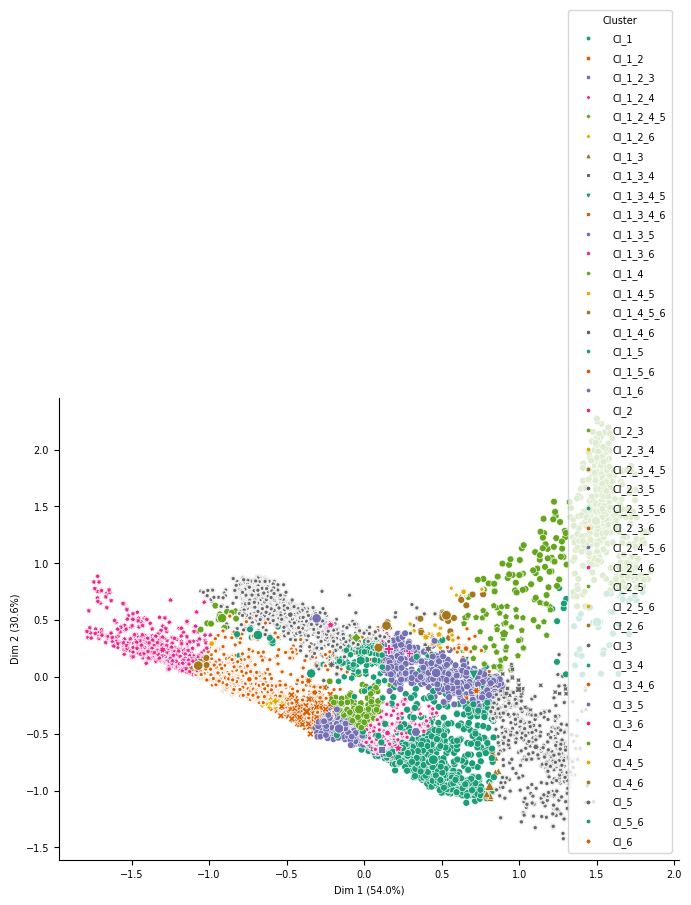

In [4]:
display_results_evidential(X, ecm_models, numeric_labels, up_low_appr=False)

## Weighted ECM (WECM)

In [5]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(5):
    model = wecm(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None")
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.12779914706346177, 0.13124960123654217, 0.13144807417669505, 0.13383566041471467, 0.1687316039708775]
ARI values: [0.3249192113054259, 0.33396825690592885, 0.37724367314312557, 0.33458998927676165, 0.3308462678991997]
NS values: [2.398984068545311, 1.8677768712189713, 2.1093936679068914, 2.4046287421199266, 2.0846077000164653]
NMI values: [0.42043574532644795, 0.4597905319708983, 0.46344676041013116, 0.46916170082603564, 0.46180725089486196]


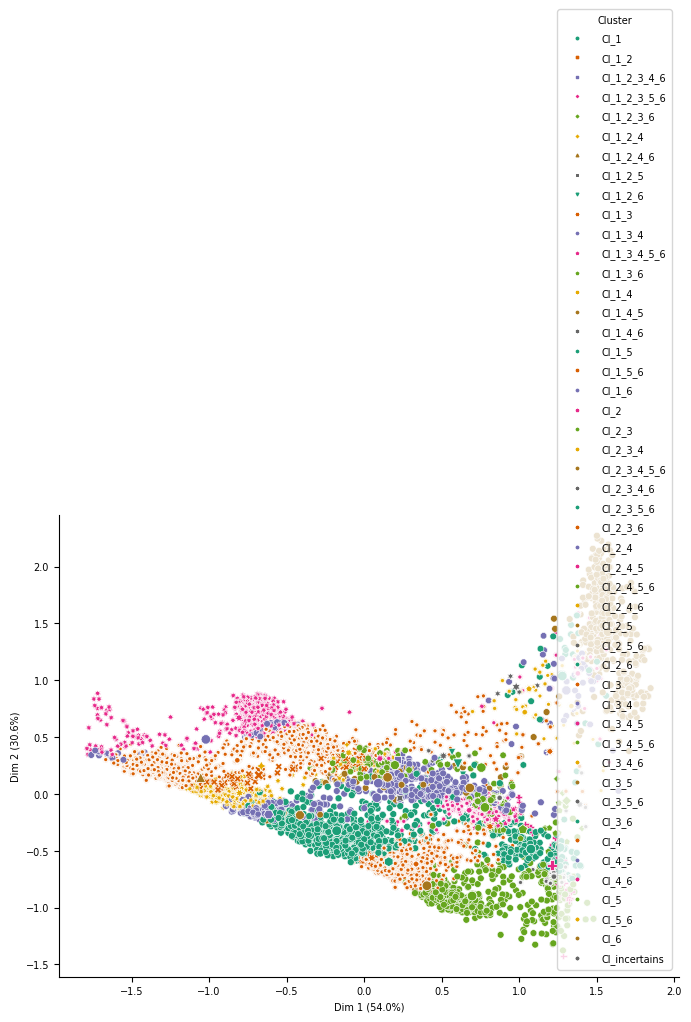

In [6]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

## WECM2

In [7]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(5):
    model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None", epsilon=1e-3)
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.6368301568534326, 0.6393022993854556, 0.6428050022500563, 0.6430765280105918, 0.6473057935408832]
ARI values: [0.44570125925537535, 0.44784555663595277, 0.4438487357761335, 0.4416766586042024, 0.4544831380215429]
NS values: [2.000720898412013, 1.9975197275706496, 1.9701816664428315, 2.0172875434911366, 2.1035234791661837]
NMI values: [0.5335050070482036, 0.5277229746281762, 0.5211640076198923, 0.5187794913474217, 0.513213351907227]


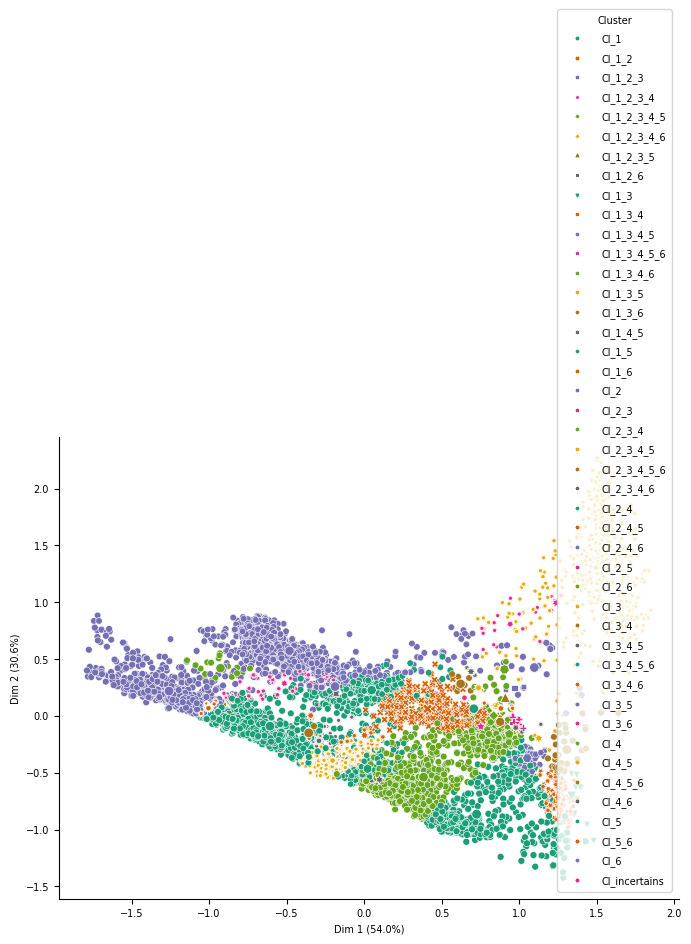

In [8]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

## Global weighted ECM - GWECM

In [3]:
%%capture
gwecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(5):
    model = gwecm(x=X, c=c, gamma=math.e**1, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None", epsilon=1e-3)
    gwecm_models = np.append(gwecm_models, model)

gwecm_models = sorted(gwecm_models, key=lambda model: model['crit'])

J values: [-4.1116256958639426, -4.104851336271007, -4.072107639611083, -4.028174764177997, -4.021309533952651]
ARI values: [0.2531668535399798, 0.24314007476915586, 0.24189506262801966, 0.25274743706857783, 0.23897492724373223]
NS values: [2.3861823768151504, 2.349960091547337, 2.379175229772748, 2.2497086678687266, 2.2734308873228524]
NMI values: [0.3773185358761369, 0.365091288132218, 0.35448735861208663, 0.37124848240665276, 0.3570844542749468]


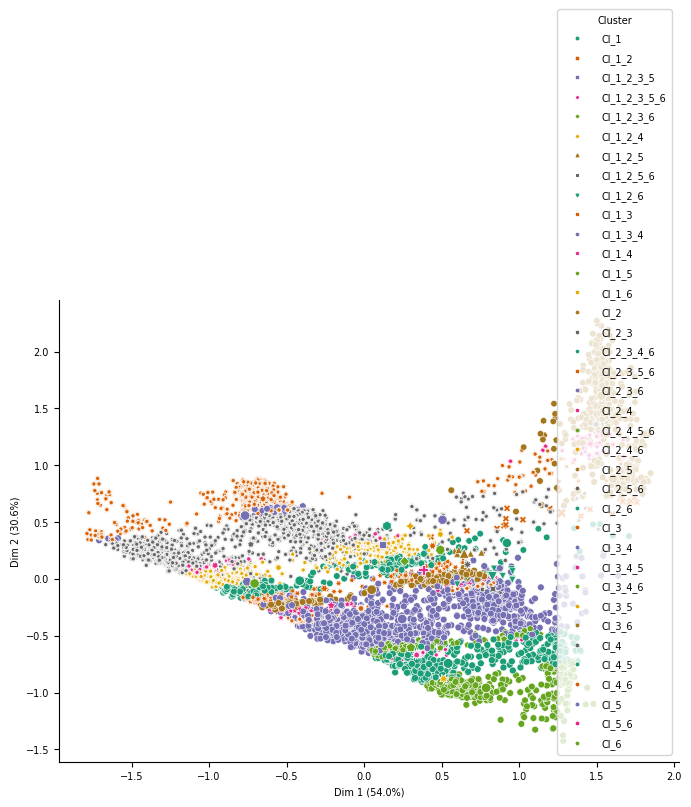

In [4]:
display_results_evidential(X, gwecm_models, numeric_labels, up_low_appr=False)

# Weighted FCM - Keller et al. 2000

In [9]:
%%capture
keller_models = np.array([])
w0 = np.ones((c, X.shape[1])) / X.shape[1]
for i in range(5):
    model = fcm_keller2000(X, c=c, w0=w0, verbose=True, epsilon=1e-6, init="None")
    keller_models = np.append(keller_models, model)
keller_models = sorted(keller_models, key=lambda model: model['obj_func'])

J values: [0.4841662114778548, 0.4841663164593257, 0.48416670218495916, 0.4841668201920388, 0.4841669697303921]
ARI values: [0.29146318537156574, 0.2916511704384488, 0.2916511704384488, 0.2914872463491176, 0.2916511704384488]
NMI values: [0.4054914987146542, 0.40606007498609037, 0.40606007498609037, 0.4055071010431494, 0.4060600749860904]


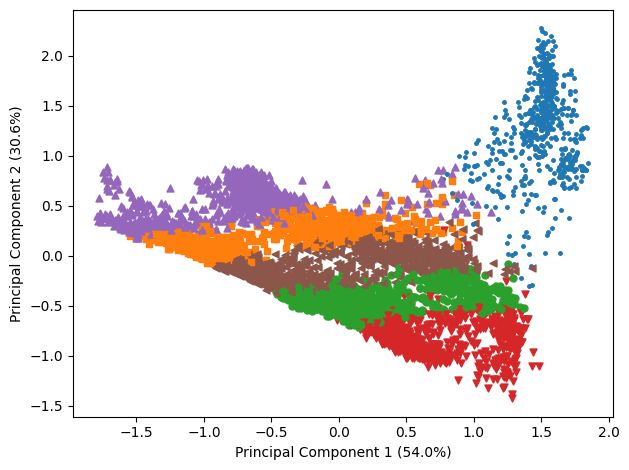

In [10]:
display_results_fuzzy_partition(X, keller_models, numeric_labels)

# Weighted FCM Wang 2004

In [11]:
%%capture
wang_models = np.array([])
for i in range(2):
    model = fcm_wang2004(X, c, w_beta=0.75, verbose=True, init="None")
    wang_models = np.append(wang_models, model)
wang_models = sorted(wang_models, key=lambda model: model['obj_func'])

J values: [0.6804088433994411, 0.7158301593464579]
ARI values: [0.5299284967834872, 0.39605369343380725]
NMI values: [0.6178527019232678, 0.49483124513921667]


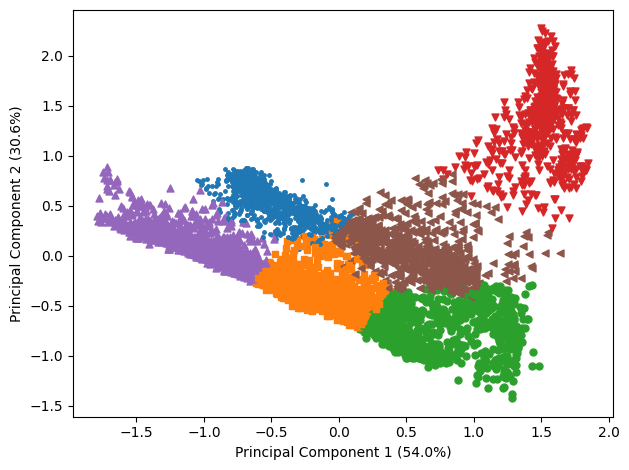

In [12]:
display_results_fuzzy_partition(X, wang_models, numeric_labels)

# SCAD1

In [13]:
%%capture
scad1_models = np.array([])
for i in range(5):
    model = scad1(X, c, verbose=True, K=2, epsilon=1e-6, init="None", stop_factor="Center")
    scad1_models = np.append(scad1_models, model)
scad1_models = sorted(scad1_models, key=lambda model: model['obj_func'])


J values: [68.71551105197355, 68.71551168661355, 68.71559714789564, 68.71560817984596, 68.71560968543983]
ARI values: [0.5341906413621735, 0.5344072334423761, 0.534247511136891, 0.5340840341104756, 0.5340840341104756]
NMI values: [0.6069710855299868, 0.6070865892294175, 0.6071512472507884, 0.6070868674936383, 0.6070868674936383]


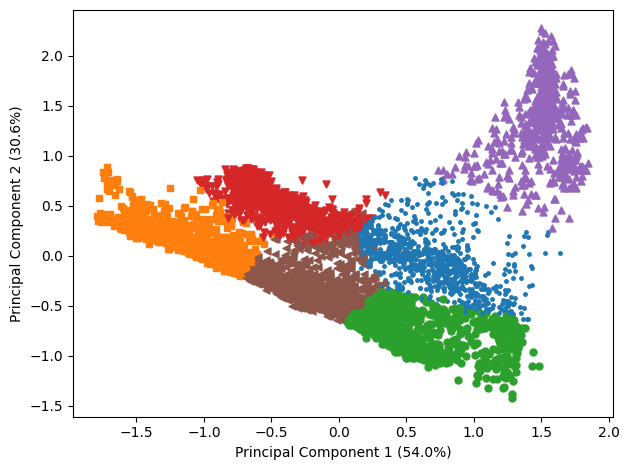

In [14]:
display_results_fuzzy_partition(X, scad1_models, numeric_labels)

# SCAD2

In [15]:
%%capture
scad2_models = np.array([])
for i in range(5):
    model = scad2(X, c, verbose=True, init="None", epsilon=1e-6, stop_factor="center")
    scad2_models = np.append(scad2_models, model)
scad2_models = sorted(scad2_models, key=lambda model: model['obj_func'])


J values: [0.5300150806640345, 0.530015083138023, 0.5300150865428972, 0.530015092822702, 0.5300152912755713]
ARI values: [0.5438106535701255, 0.5438106535701255, 0.5438106535701255, 0.5438106535701255, 0.5438106535701255]
NMI values: [0.608097346336062, 0.6080973463360623, 0.6080973463360623, 0.6080973463360623, 0.6080973463360622]


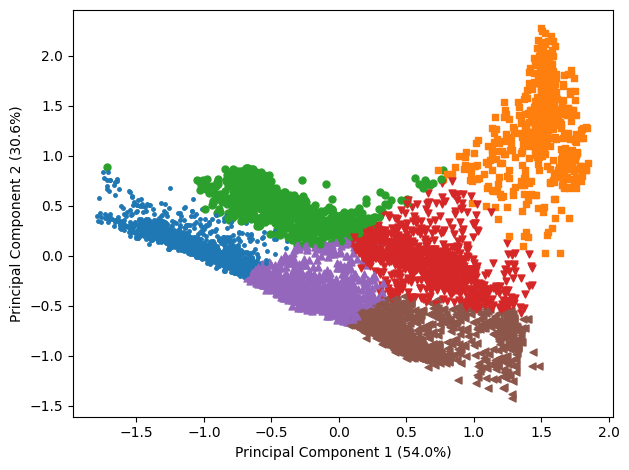

In [16]:
display_results_fuzzy_partition(X, scad2_models, numeric_labels)

# IFWFCM - Xing et al. 2014

In [17]:
%%capture
ifwfcm_models = np.array([])
for i in range(5):
    model = ifwfcm_xing2014(X, c, verbose=True, init="None")
    ifwfcm_models = np.append(ifwfcm_models, model)
ifwfcm_models = sorted(ifwfcm_models, key=lambda model: model['obj_func'])

J values: [0.6031365161022806, 0.6031816974692799, 0.6038961421843937, 0.6049867036003296, 0.6051244503346058]
ARI values: [0.49306926840185267, 0.5332301847086133, 0.4612707835776287, 0.42783992335307897, 0.43375502592098525]
NMI values: [0.5695011925861636, 0.6115272280900933, 0.5355441390943174, 0.5094130537899939, 0.5141220807968487]


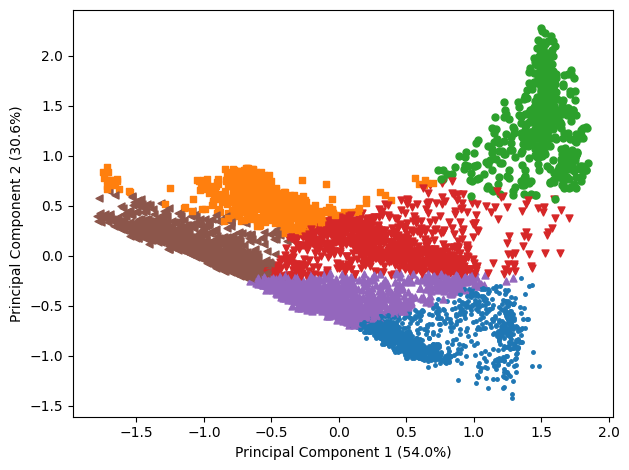

In [18]:
display_results_fuzzy_partition(X, ifwfcm_models, numeric_labels)

# IFWFCM_KD Xing 2014

In [19]:
%%capture
ifwfcm_kd_models = np.array([])
for i in range(5):
    model = ifwfcm_kd_xing2014(X, c, verbose=True, epsilon=1e-6, init="None")
    ifwfcm_kd_models = np.append(ifwfcm_kd_models, model)
ifwfcm_kd_models = sorted(ifwfcm_kd_models, key=lambda model: model['obj_func'])

J values: [15.544843972229977, 15.544843998709162, 15.544844471389588, 15.544857613289453, 15.601859305563092]
ARI values: [0.5155895446426507, 0.5155895446426507, 0.5156285584843396, 0.5166836208504835, 0.4400556694423423]
NMI values: [0.5931728629544878, 0.5931728629544876, 0.5933160918756616, 0.5946737452369244, 0.5119884315058008]


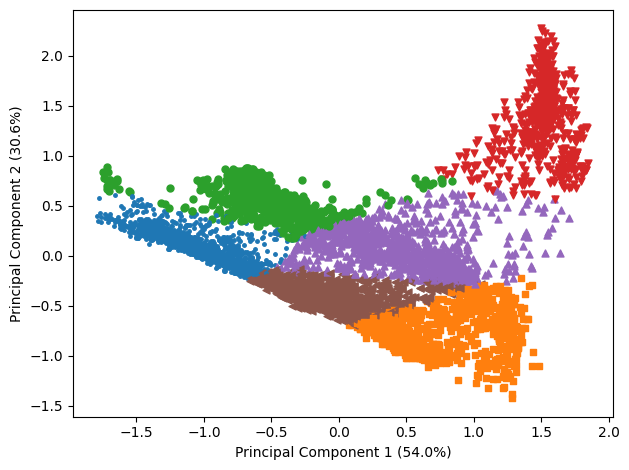

In [20]:
display_results_fuzzy_partition(X, ifwfcm_kd_models, numeric_labels)